# Imports and Reading data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [ ]:
df = pd.read_csv('STO-const_decay-500k.csv')

# Data understanding

In [ ]:
df.shape

# Check the number of rows and columns.

In [ ]:
df.head(5)

In [ ]:
df.dtypes

# Data preparation

In [ ]:
df.isna().sum()

# Check for missing values before deciding whether rows need to be removed.

# Feature understanding

In [ ]:
cv = df['converged'].value_counts().head(10).plot(kind = 'bar', title = 'Convergence count')

cv.set_xlabel('Converged')
cv.set_ylabel('Counts')

# Inspect the balance between converged and non-converged samples.

In [ ]:
ct = df['convergence_time'].plot(kind = 'kde',
                title = 'Convergence time count')
ct.set_xlabel('Convergence time')
ct.set_ylabel('Frequency')

# Inspect the distribution of convergence times.

In [ ]:
sum(df['convergence_time'] < 10)

# Count combinations with convergence time below 10 seconds.

In [ ]:
sum(df['convergence_time'] < 5)

# Count combinations with convergence time below 5 seconds.


# Feature relationships

In [ ]:
for i in range (df.shape[1] - 2):
    df.plot(kind = 'scatter',
            x = i,
            y = 'convergence_time')
    plt.show()


In [ ]:
sns.pairplot(df,
             vars = ['optimizer_gain','dither_amplitude','dither_frequency', 'convergence_time'])
plt.show()


In [ ]:
sns.heatmap(df.drop(columns = 'converged').corr(), annot = True)


In [ ]:
dfcut = df[df['convergence_time'] < 10]
for i in range (dfcut.shape[1] - 2):
    dfcut.plot(kind = 'scatter',
            x = i,
            y = 'convergence_time')
    plt.show()


In [ ]:
sns.pairplot(dfcut,
             vars = ['optimizer_gain','dither_amplitude','dither_frequency', 'convergence_time'])
plt.show()


In [ ]:
sns.heatmap(dfcut.drop(columns = 'converged').corr(), annot = True)


I think it would be useful to plot a 3d plot to visualize where the false predictions are.

# Visualization

In [ ]:
import plotly.express as px

In [ ]:
fig500k = px.scatter_3d(df,
                    x = 'optimizer_gain',
                    y = 'dither_amplitude',
                    z = 'dither_frequency',
                    color = 'convergence_time',
                    title = '3D scatter',
                    labels = {'optimizer_gain' : 'Optimizer gain',
                              'dither_amplitude' : 'Dither amplitude',
                              'dither_frequency' : 'Dither Frequency'})
fig500k.update_traces(marker=dict(size=3))
fig500k.show()

In [ ]:
# Exporting the plot (put it comment as I would run the notebook all over every time I open)
# fig500k.write_html("3dscatter500k.html")

# Modelling: Classification

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

torch.manual_seed(1)  #reproducible weights and batch shuffling

In [21]:
# Adding more features to the dataset
df['log10gain'] = np.log10(df['optimizer_gain'])
df['sinfre'] = np.sin(df['dither_frequency'])
df['product'] = df['optimizer_gain'] * df['dither_amplitude'] * df['sinfre']

In [22]:
# Create training sets

X = df.drop(columns=['convergence_time', 'converged'])
y = df['converged']

# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
X_cv, X_test, y_cv, y_test = train_test_split(X_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del X_, y_

In [ ]:
# Convert to float32 tensors
Xtr = torch.tensor(X_train.values, dtype=torch.float32)
ytr = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
Xcv = torch.tensor(X_cv.values, dtype=torch.float32)
ycv = torch.tensor(y_cv.values, dtype=torch.float32).reshape(-1, 1)

# Mini-batches of 100, reshuffled every epoch
train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=5000, shuffle=True)

In [24]:
# Defining models

n = Xtr.shape[1]  #number of input features

model1 = nn.Sequential(
    nn.Linear(n, 32), nn.ReLU(),
    nn.Linear(32, 16), nn.ReLU(),
    nn.Linear(16, 1)
)

model2 = nn.Sequential(
    nn.Linear(n, 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 16), nn.ReLU(),
    nn.Linear(16, 1)
)

In [25]:
def train(model, epochs=300, lr=0.01):
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'loss': [], 'val_loss': []}

    for epoch in range(epochs):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            history['loss'].append(loss_fn(model(Xtr), ytr).item())
            history['val_loss'].append(loss_fn(model(Xcv), ycv).item())

    return history

def predict_logits(model, X):
    with torch.no_grad():
        return model(X)

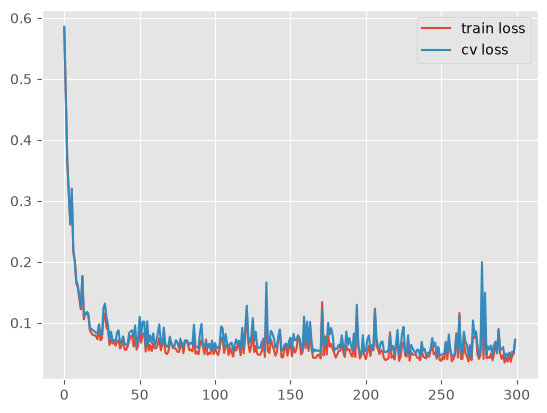

In [26]:
# Train with model 1

history1 = train(model1)
plt.plot(history1['loss'], label='train loss')
plt.plot(history1['val_loss'], label='cv loss')
plt.legend()
plt.show()

In [27]:
logits1 = predict_logits(model1, Xcv)
probs1 = torch.sigmoid(logits1).numpy() # convert logit to probability
y_pred1 = (probs1 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy1 = accuracy_score(y_cv, y_pred1)
print(f"CV accuracy: {accuracy1:.3f}")

CV accuracy: 0.969


In [28]:
print(confusion_matrix(y_cv, y_pred1))
print(classification_report(y_cv, y_pred1))

[[ 533   47]
 [  15 1405]]
              precision    recall  f1-score   support

           0       0.97      0.92      0.95       580
           1       0.97      0.99      0.98      1420

    accuracy                           0.97      2000
   macro avg       0.97      0.95      0.96      2000
weighted avg       0.97      0.97      0.97      2000



In [29]:
train_logits1 = predict_logits(model1, Xtr)
train_probs1 = torch.sigmoid(train_logits1).numpy()
train_pred1 = (train_probs1 > 0.5).astype(int).flatten()
train_acc1 = accuracy_score(y_train, train_pred1)
print(f"Train accuracy: {train_acc1:.3f}")

Train accuracy: 0.969


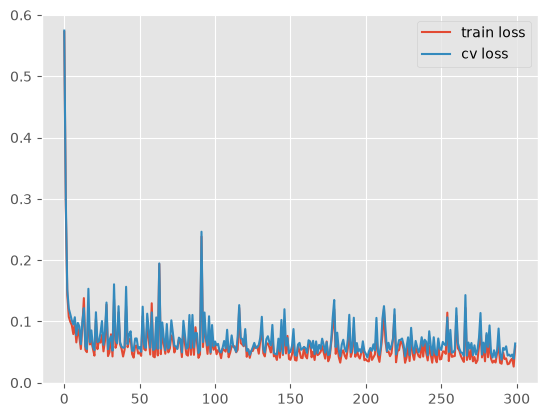

In [30]:
# Train with model 2

history2 = train(model2)
plt.plot(history2['loss'], label='train loss')
plt.plot(history2['val_loss'], label='cv loss')
plt.legend()
plt.show()

In [31]:
logits2 = predict_logits(model2, Xcv)
probs2 = torch.sigmoid(logits2).numpy() # convert logit to probability
y_pred2 = (probs2 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy2 = accuracy_score(y_cv, y_pred2)
print(f"CV accuracy: {accuracy2:.3f}")

CV accuracy: 0.974


In [32]:
print(confusion_matrix(y_cv, y_pred2))
print(classification_report(y_cv, y_pred2))

[[ 573    7]
 [  45 1375]]
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       580
           1       0.99      0.97      0.98      1420

    accuracy                           0.97      2000
   macro avg       0.96      0.98      0.97      2000
weighted avg       0.98      0.97      0.97      2000



In [33]:
train_logits2 = predict_logits(model2, Xtr)
train_probs2 = torch.sigmoid(train_logits2).numpy()
train_pred2 = (train_probs2 > 0.5).astype(int).flatten()
train_acc2 = accuracy_score(y_train, train_pred2)
print(f"Train accuracy: {train_acc2:.3f}")

Train accuracy: 0.975


I think there is still room for improvement, but we would have to analyse the wrong predictions first.

In [ ]:
# Find where the false positives are
false_positive1 = (y_pred1 == 1) & (y_cv == 0)
X_cv1_df = pd.DataFrame(X_cv, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv1_df[false_positive1].describe())

false_positive2 = (y_pred2 == 1) & (y_cv == 0)
X_cv2_df = pd.DataFrame(X_cv, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv2_df[false_positive2].describe())

In [ ]:
# Merge the false positives into 1 table

fp1 = X_cv1_df[false_positive1]
fp2 = X_cv2_df[false_positive2]

fp = pd.concat([fp1, fp2], ignore_index=True)
print(fp.describe())

In [ ]:
# Drop duplicated rows of fp

fp = fp.loc[~fp.duplicated()].reset_index(drop = True)
print(fp.describe())

In [ ]:
# Find where the false negatives are
false_negative1 = (y_pred1 == 0) & (y_cv == 1)
X_cv1_df = pd.DataFrame(X_cv, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv1_df[false_negative1].describe())

false_negative2 = (y_pred2 == 0) & (y_cv == 1)
X_cv2_df = pd.DataFrame(X_cv, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv2_df[false_negative2].describe())

In [ ]:
# Merge the false negatives into 1 table

fn1 = X_cv1_df[false_negative1]
fn2 = X_cv2_df[false_negative2]

fn = pd.concat([fn1, fn2], ignore_index=True)
print(fn.describe())

In [ ]:
# Drop duplicated rows of fn

fn = fn.loc[~fn.duplicated()].reset_index(drop = True)
print(fn.describe())

In [ ]:
fp

I realized that I did not pay enough attention to thhe dither amplitude. 
I will generate another dataset with wider range of dither amplitude (and dither frequency) to hopefully get a symmetric 3d plot.
I need to increase the range of all 3 parameters.

    % ESC parameters range
    optimizer_gain_range   = [1e-4, 0.15];
    dither_amplitude_range = [0.01, 1];
    dither_frequency_range = [0.1, 1.5];  

It seems like the dither frequency still have plenty of space to increase
The optimizer gain depends on the convergence time allowed (in this case 100 seconds) so it can go really low.

    optimizer_gain_range   = [1e-5, 0.25];
    dither_amplitude_range = [1e-5, 2.5];
    dither_frequency_range = [1e-5, 3];  

    need checking

The points are probably unnecersarily densed. 
I would keep the same the number of combinations and increase the range to figure out the shape first 
The dither frequency still has a lot of space, probably up to 20 (?) and even lower
Optimizer gain can probably go up to 1
Dither amplitude goes much lower and up to 5+

1M is too large for the browser so I can only choose randomly 500k

1. It seems like doesn't matter how long I go with the amplitude and how high with the frequency, they would still have nice convergence time
2. There are some "random points" that would "unexpectedly" converge

    optimizer_gain_range   = [1e-50, 5];
    dither_amplitude_range = [1e-708, 20];
    dither_frequency_range = [1e-708, 100];  